In [1]:
import sys
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from copy import deepcopy

# Model Imports
from hospital_model.simulate_model import simulate_model
from hospital_model.scenario_helpers import (
    get_scenario_params,
    compare_healthcare_systems, get_healthcare_systems
)
from hospital_model.scenarios import (
    SCENARIO_REGISTRY, AGE_PARAMS_EMPIRICAL, CONTACT_MATRIX_DEFAULT,
    INTERVENTION_EARLY_STRONG, INTERVENTION_CYCLICAL,
    VACCINE_PROFILES, HEALTHCARE_SYSTEM_URBAN
)

# Plotting Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
COLORS = sns.color_palette("deep")

In [2]:
def plot_experiment_results(results_dict, title, metric='H_ward_total', ylabel='Ward Occupancy'):
    """Generic helper to plot a metric across multiple scenarios."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for name, res in results_dict.items():
        ax.plot(res['times'], res[metric], label=name, linewidth=2)
        
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel(ylabel)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax

def check_conservation(results, initial_pop, tolerance=1e-5):
    """Verify population conservation."""
    # Sum of all compartments
    total_pop = np.zeros_like(results['times'])
    
    # Add all tracked compartments
    # Note: We need to sum all compartment arrays. 
    # The results dict contains lists of arrays for each compartment (one per age group)
    # We need to sum across age groups and then across compartments
    
    compartment_names = [
        'S', 'E', 'I', 'X_queued', 'X_admitted', 'H_ward', 'H_icu', 'R', 'D',
        'S_vax', 'E_vax', 'I_vax', 'X_queued_vax', 'X_admitted_vax', 
        'H_ward_vax', 'H_icu_vax', 'R_vax', 'D_vax'
    ]
    
    for name in compartment_names:
        if name in results:
            # results[name] is a list of arrays (one per age group)
            # Sum across age groups
            comp_total = np.sum(results[name], axis=0)
            total_pop += comp_total
             
    # Check deviation
    deviation = np.abs(total_pop - initial_pop)
    max_dev = np.max(deviation)
    passed = max_dev < tolerance
    return passed, max_dev, total_pop

Running Experiment 1: Split-X Consistency...
Split-X Consistency: PASSED
  Max deviation: 3.64e-11


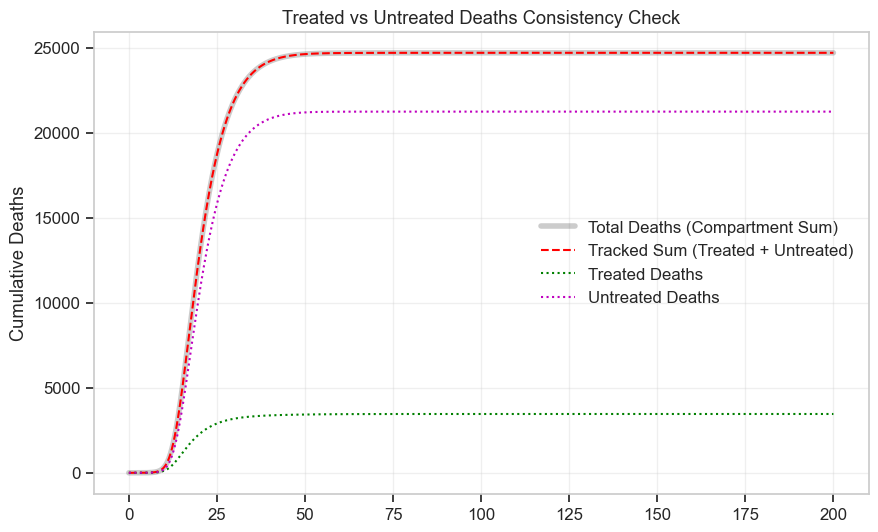

In [3]:
# Experiment 1: Split-X Consistency

print("Running Experiment 1: Split-X Consistency...")

# Use a scenario with high capacity stress to generate untreated deaths
params = get_scenario_params('stress_test')
res = simulate_model(**params)

# Sum treated and untreated deaths (summing across age groups)
d_treated = np.sum(res['D_treated'], axis=0)
d_untreated = np.sum(res['D_untreated'], axis=0)
d_total_tracked = d_treated + d_untreated

# Also check vaccinated deaths if they exist
if 'D_vax_treated' in res:
    d_vax_treated = np.sum(res['D_vax_treated'], axis=0)
    d_vax_untreated = np.sum(res['D_vax_untreated'], axis=0)
    d_total_tracked += d_vax_treated + d_vax_untreated

# Compare with main D compartment (D + D_vax)
d_main = res['D_total']

# Calculate deviation
deviation = np.abs(d_main - d_total_tracked)
max_dev = np.max(deviation)
passed = max_dev < 1e-5

print(f"Split-X Consistency: {'PASSED' if passed else 'FAILED'}")
print(f"  Max deviation: {max_dev:.2e}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(res['times'], d_main, 'k-', linewidth=4, alpha=0.2, label='Total Deaths (Compartment Sum)')
ax.plot(res['times'], d_total_tracked, 'r--', label='Tracked Sum (Treated + Untreated)')
ax.plot(res['times'], d_treated, 'g:', label='Treated Deaths')
ax.plot(res['times'], d_untreated, 'm:', label='Untreated Deaths')
ax.set_title('Treated vs Untreated Deaths Consistency Check')
ax.set_ylabel('Cumulative Deaths')
ax.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../results/split_x_consistency_check.png")
plt.show()

# Healthcare Capacity Dynamics

These experiments investigate how hospital capacity constraints and the "hardness" of those constraints (Hill coefficients) affect mortality outcomes.

Running Experiment 2: Hill Coefficient Sensitivity...


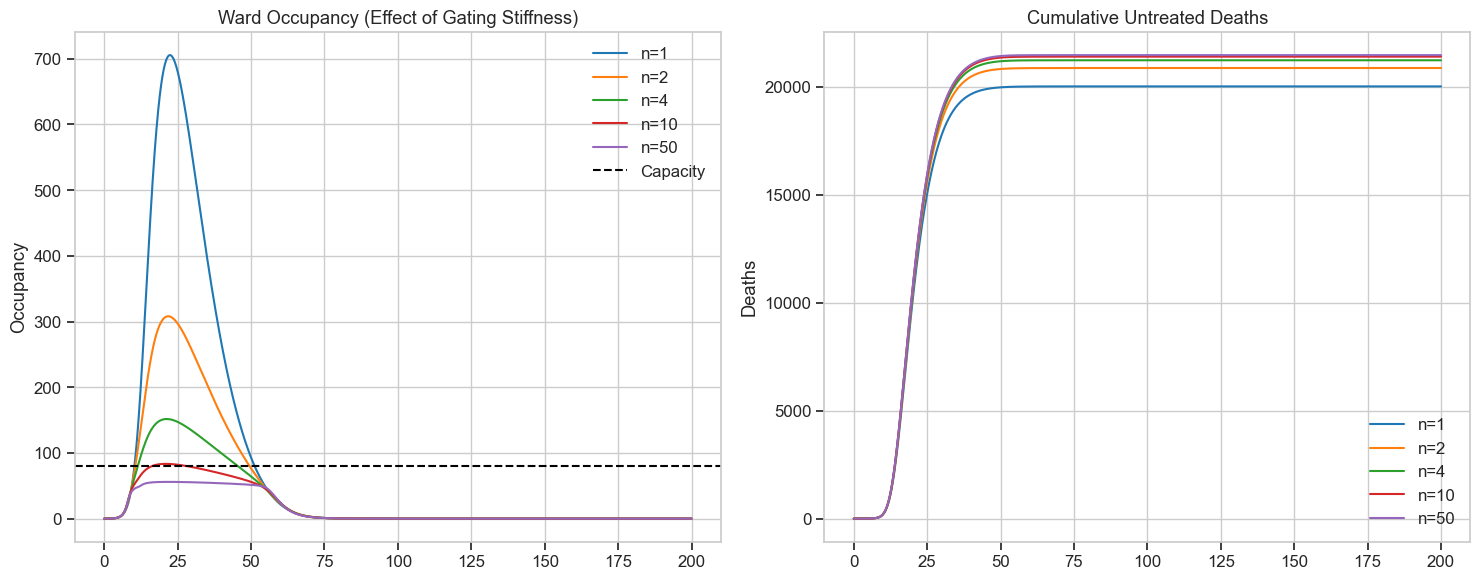

In [4]:
# Experiment 2: Hill Coefficient Sensitivity

print("Running Experiment 2: Hill Coefficient Sensitivity...")

base_params = get_scenario_params('stress_test')
# Ensure we have a scenario where capacity is challenged

hill_values = [1, 2, 4, 10, 50]
results_exp2 = {}

for n in hill_values:
    p = deepcopy(base_params)
    p['capacity_config']['hill_coef_ward'] = n
    p['capacity_config']['hill_coef_icu'] = n
    results_exp2[f'n={n}'] = simulate_model(**p)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Ward Occupancy vs Capacity
capacity = base_params['capacity_config']['ward_capacity']
for name, res in results_exp2.items():
    ax1.plot(res['times'], res['H_ward_total'], label=name)
ax1.axhline(capacity, color='k', linestyle='--', label='Capacity')
ax1.set_title('Ward Occupancy (Effect of Gating Stiffness)')
ax1.set_ylabel('Occupancy')
ax1.legend()

# Plot 2: Untreated Deaths
for name, res in results_exp2.items():
    # Sum untreated deaths
    untreated = np.sum(res['D_untreated'], axis=0)
    ax2.plot(res['times'], untreated, label=name)
ax2.set_title('Cumulative Untreated Deaths')
ax2.set_ylabel('Deaths')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/hill_coef_sensitivity.png')
plt.show()

Running Experiment 3: Healthcare System Comparison...


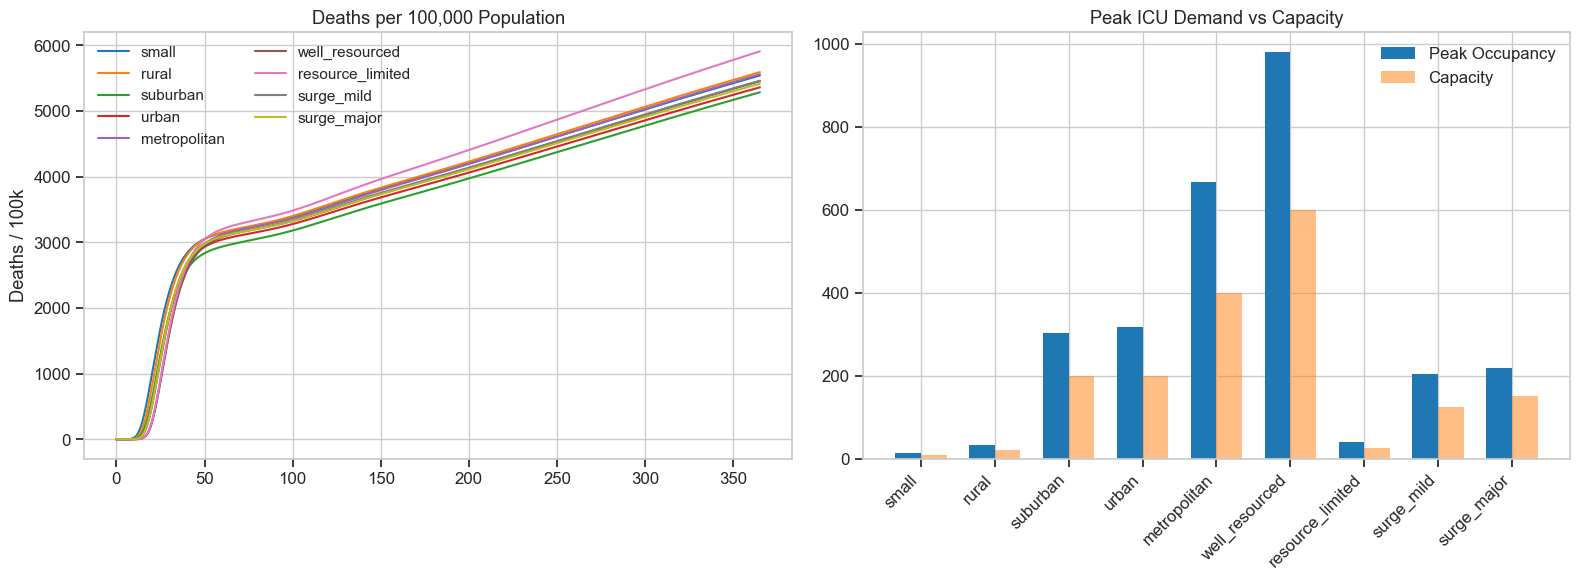

In [5]:
# Experiment 3: Healthcare System Comparison

print("Running Experiment 3: Healthcare System Comparison...")

systems = list(get_healthcare_systems().keys())
scenarios_exp3 = compare_healthcare_systems('covid_delta', systems)

results_exp3 = {}
for name, params in scenarios_exp3.items():
    results_exp3[name] = simulate_model(**params)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Deaths per 100k
for name, res in results_exp3.items():
    # Get population for this system
    pop = sum(scenarios_exp3[name]['age_pops'])
    d_total = np.array(res['D_total']) if isinstance(res['D_total'], list) else res['D_total']
    deaths_per_100k = (d_total / pop) * 100000
    axes[0].plot(res['times'], deaths_per_100k, label=name)
axes[0].set_title('Deaths per 100,000 Population')
axes[0].set_ylabel('Deaths / 100k')
axes[0].legend(fontsize='small', ncol=2)

# Plot 2: Peak ICU Occupancy vs Capacity
names = []
peaks = []
caps = []
for name, res in results_exp3.items():
    names.append(name)
    peaks.append(np.max(res['H_icu_total']))
    caps.append(scenarios_exp3[name]['capacity_config']['icu_capacity'])

x = np.arange(len(names))
width = 0.35
axes[1].bar(x - width/2, peaks, width, label='Peak Occupancy')
axes[1].bar(x + width/2, caps, width, label='Capacity', alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=45, ha='right')
axes[1].set_title('Peak ICU Demand vs Capacity')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/healthcare_system_comparison.png')
plt.show()

In [6]:
from scenario_helpers import create_intervention_comparison

print("Running Experiment 4: Intervention Strategy Comparison...")

# Define a set of interventions to compare
interventions_map = {
    'No Intervention': [],
    'Early Strong (Day 14)': INTERVENTION_EARLY_STRONG,
    'Cyclical (On/Off)': INTERVENTION_CYCLICAL,
    'Late Response (Day 45)': [{'start_day': 45, 'end_day': 105, 'transmission_reduction': 0.6}]
}

# Use the helper function - it handles the scenarios structure for you!
scenarios_exp4 = create_intervention_comparison('covid_delta', interventions_map)

results_exp4 = {}
for name, params in scenarios_exp4.items():
    results_exp4[name] = simulate_model(**params)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Infections
for name, res in results_exp4.items():
    axes[0].plot(res['times'], res['I_total'], label=name)
axes[0].set_title('Infections')
axes[0].legend()

# Deaths
for name, res in results_exp4.items():
    axes[1].plot(res['times'], res['D_total'], label=name)
axes[1].set_title('Cumulative Deaths')

plt.tight_layout()
plt.savefig('../results/intervention_comparison.png')
plt.show()

ModuleNotFoundError: No module named 'scenario_helpers'

# Sensitivity

This section synthesizes multiple parameters to explore interaction effects.

In [ ]:
# Experiment 5: Multi-Parameter Heatmaps (Beta vs Capacity)

print("Running Experiment 5: Multi-Parameter Heatmaps...")

base_params = get_scenario_params('covid_delta')

# Define ranges
betas = np.linspace(0.1, 0.5, 10)
capacities = np.linspace(25, 400, 10)

# Grid search
results_grid = np.zeros((len(betas), len(capacities)))

for i, beta in enumerate(betas):
    for j, cap in enumerate(capacities):
        p = deepcopy(base_params)
        p['beta_base'] = beta
        p['capacity_config']['ward_capacity'] = cap
        p['capacity_config']['icu_capacity'] = cap * 0.25 # Maintain ratio
        
        res = simulate_model(**p)
        results_grid[i, j] = res['D_total'][-1]

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(results_grid, xticklabels=np.round(capacities, 0), yticklabels=np.round(betas, 2),
            cmap='viridis', annot=True, fmt='.0f', ax=ax)

ax.set_title('Total Deaths: Transmission Rate vs Hospital Capacity')
ax.set_xlabel('Ward Capacity')
ax.set_ylabel('Beta (Transmission Rate)')
ax.invert_yaxis() # Standard plot orientation
plt.savefig('../results/heatmap_beta_vs_capacity.png')
plt.show()

# Numerical Methods Comparison

This section compares different ODE solvers to ensure numerical stability, especially for stiff systems (e.g., with fast rates or hard capacity limits).

In [ ]:
# Solver Comparison

print("Running Solver Comparison...")

base_params = get_scenario_params('stress_test')
# Use a stiff scenario (high transmission, sharp capacity limits)
base_params['capacity_config']['hill_coef_ward'] = 20 # Very sharp cutoff -> stiff
base_params['beta_base'] = 0.5

solvers = [
    ('odeint', 'LSODA'),
    ('solve_ivp', 'RK45'),
    ('solve_ivp', 'BDF'),
    ('solve_ivp', 'Radau')
]

results_solver = {}
import time

for func, method in solvers:
    p = deepcopy(base_params)
    p['solver'] = func
    p['solver_method'] = method
    
    start = time.time()
    try:
        res = simulate_model(**p)
        duration = time.time() - start
        results_solver[f'{func}/{method} ({duration:.3f}s)'] = res
    except Exception as e:
        print(f"Solver {func}/{method} failed: {e}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Ward Occupancy (Zoom in on peak)
for name, res in results_solver.items():
    ax1.plot(res['times'], res['H_ward_total'], label=name, alpha=0.8)
ax1.set_title('Ward Occupancy (Stiff System)')
ax1.set_ylabel('Occupancy')
ax1.legend()

# Plot 2: Difference from LSODA (Reference)
ref_key = [k for k in results_solver.keys() if 'LSODA' in k][0]
ref_res = results_solver[ref_key]

for name, res in results_solver.items():
    if name == ref_key:
        continue
    # Handle D_total which can be array or list
    d_total = np.array(res['D_total']) if isinstance(res['D_total'], list) else res['D_total']
    d_total_ref = np.array(ref_res['D_total']) if isinstance(ref_res['D_total'], list) else ref_res['D_total']
    
    diff = d_total - d_total_ref
    ax2.plot(res['times'], diff, label=f'{name} - LSODA')

ax2.set_title('Difference in Cumulative Deaths vs LSODA')
ax2.set_ylabel('Difference (People)')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/solver_comparison.png')
plt.show()